### Dataset preview

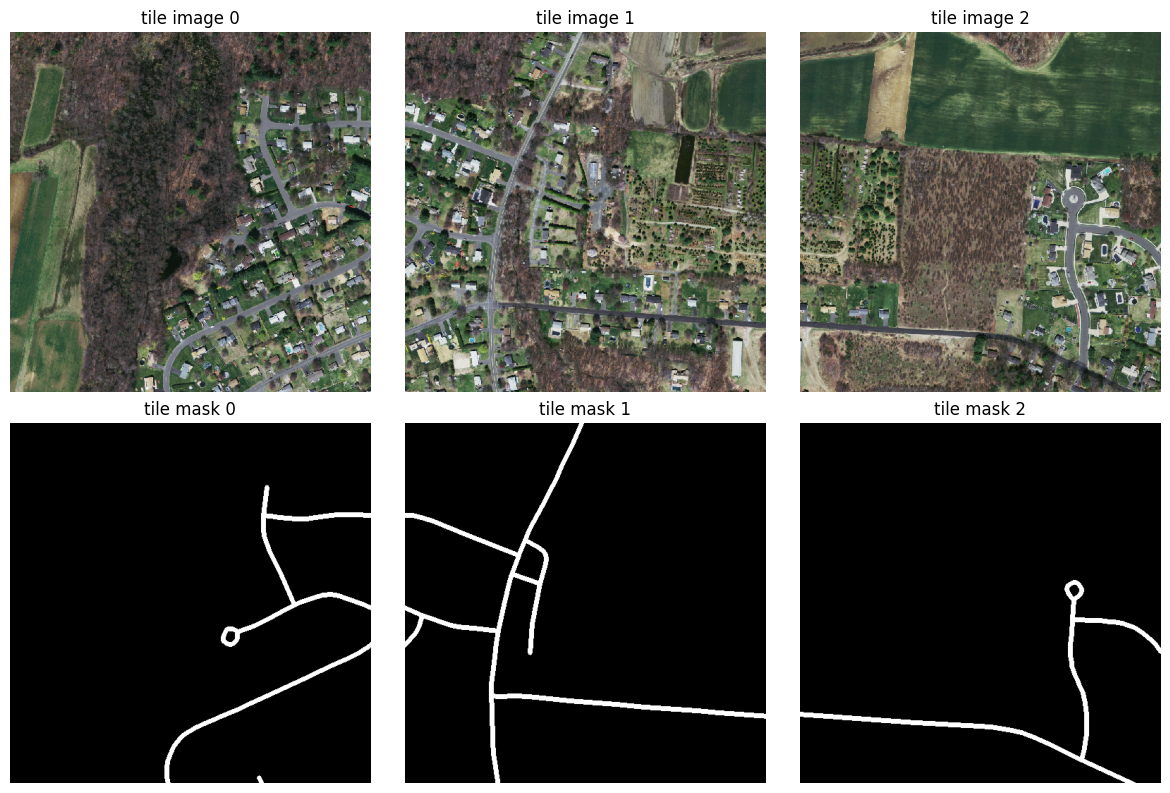

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from dataset import RoadsDataset

PREVIEW_IMG_DIR = "data/tiff/train/"
PREVIEW_MASK_DIR = "data/tiff/train_labels/"
PREVIEW_TILE_SIZE = 512
PREVIEW_STRIDE = 512

raw_ds = RoadsDataset(
    PREVIEW_IMG_DIR,
    PREVIEW_MASK_DIR,
    tile_size=PREVIEW_TILE_SIZE,
    stride=PREVIEW_STRIDE,
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for col, idx in enumerate([0, 1, 2]):
    image, mask = raw_ds[idx]
    axes[0, col].imshow(image)
    axes[0, col].set_title(f"tile image {idx}")
    axes[1, col].imshow(mask, cmap="gray")
    axes[1, col].set_title(f"tile mask {idx}")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()


### Transform preview

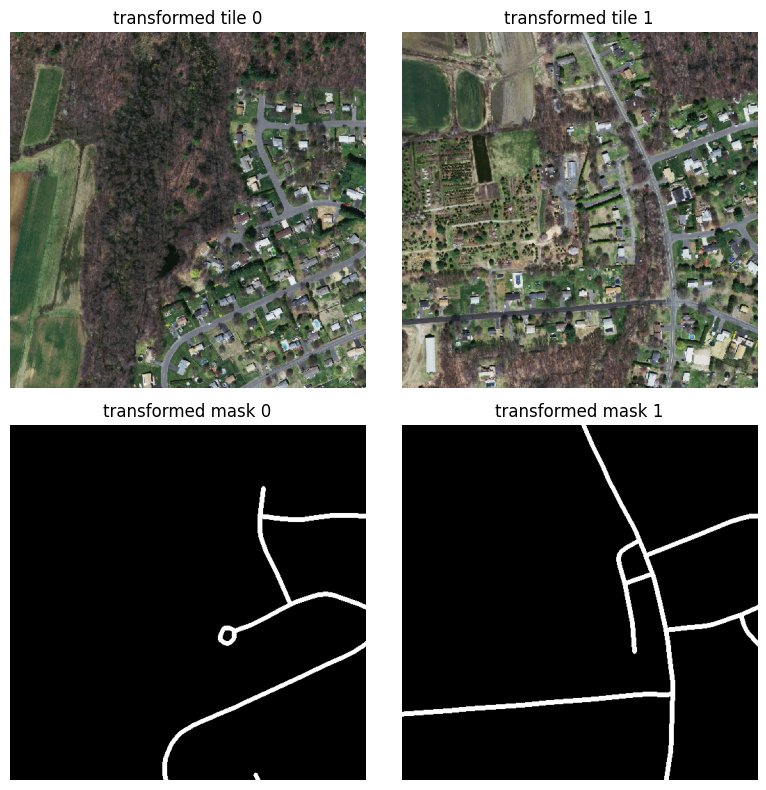

In [2]:
preview_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)

transformed_ds = RoadsDataset(
    PREVIEW_IMG_DIR,
    PREVIEW_MASK_DIR,
    transform=preview_transform,
    tile_size=PREVIEW_TILE_SIZE,
    stride=PREVIEW_STRIDE,
)
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def show_tensor_image(tensor):
    image = (tensor.cpu() * std + mean).clamp(0, 1)
    return image.permute(1, 2, 0)

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
for col, idx in enumerate([0, 1]):
    image, mask = transformed_ds[idx]
    axes[0, col].imshow(show_tensor_image(image))
    axes[0, col].set_title(f"transformed tile {idx}")
    axes[1, col].imshow(mask, cmap="gray")
    axes[1, col].set_title(f"transformed mask {idx}")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()


### Model
UNet-like architecture

In [3]:
import torch
import torch.nn as nn
import torchvision.transforms.functional as tf

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)
    
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64,128,256,512]):
        super().__init__()
        self.ups = nn.ModuleList()
        self.downs = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Down part of UNet
        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Up part of UNet
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip_connection = skip_connections[idx//2]

            if x.shape != skip_connection.shape:
                x = tf.resize(x, size=skip_connection.shape[2:])

            concat_skip = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](concat_skip)

        return self.final_conv(x)

### Train loop

In [ ]:
import torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from utils import update_iou_stats

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
NUM_EPOCHS = 10
NUM_WORKERS = 2
TILE_SIZE = 512
TRAIN_STRIDE = 512
INFER_STRIDE = 256
PIN_MEMORY = True
LOAD_MODEL = False

CHECKPOINT_PATH = "best_unet.pth"
TRAIN_IMG_DIR = "data/tiff/train/"
TRAIN_MASK_DIR = "data/tiff/train_labels/"
VAL_IMG_DIR = "data/tiff/val/"
VAL_MASK_DIR = "data/tiff/val_labels/"
TEST_IMG_DIR = "data/tiff/test/"
TEST_MASK_DIR = "data/tiff/test_labels/"

def train_one_epoch(model, loader, optimizer, loss_fn, scaler):
    model.train()

    total_loss = 0.0
    total_samples = 0

    total_intersection = 0.0
    total_union = 0.0

    loop = tqdm(loader)
    for batch_idx, (data, targets) in enumerate(loop):
        data = data.to(device=DEVICE)
        targets = targets.unsqueeze(1).to(device=DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            logits = model(data)
            loss = loss_fn(logits, targets)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        intersection, union = update_iou_stats(logits, targets)
        total_intersection += intersection.item()
        total_union += union.item()

        # update tqdm loop
        loop.set_postfix(loss=loss.item())

    total_loss = total_loss / total_samples
    total_iou = total_intersection / (total_union + 1e-7)

    return total_loss, total_iou


from dataset import make_tile_starts
import os
import tifffile as tiff

@torch.no_grad()
def predict_full_image(model, image_path, transform, tile_size, stride):
    model.eval()
    image = tiff.imread(image_path)
    height, width = image.shape[:2]

    pred_sum = torch.zeros((height, width), dtype=torch.float32)
    pred_count = torch.zeros((height, width), dtype=torch.float32)

    for y in make_tile_starts(height, tile_size, stride):
        for x in make_tile_starts(width, tile_size, stride):
            tile = image[y:y + tile_size, x:x + tile_size]
            tensor = transform(image=tile)["image"].unsqueeze(0).to(DEVICE)

            with torch.amp.autocast("cuda"):
                logits = model(tensor)

            probs = torch.sigmoid(logits)[0, 0].cpu()
            pred_sum[y:y + tile_size, x:x + tile_size] += probs
            pred_count[y:y + tile_size, x:x + tile_size] += 1

    return image, pred_sum / pred_count


def evaluate(model, image_dir, mask_dir, transform, tile_size, stride):
    total_loss = 0.0
    total_intersection = 0.0
    total_union = 0.0

    for image_name in tqdm(sorted(os.listdir(image_dir))):
        image_path = os.path.join(image_dir, image_name)
        mask_path = os.path.join(mask_dir, f"{os.path.splitext(image_name)[0]}.tif")

        _, pred = predict_full_image(model, image_path, transform, tile_size, stride)
        target = torch.from_numpy((tiff.imread(mask_path) > 0).astype("float32"))

        loss = F.binary_cross_entropy(pred.unsqueeze(0).unsqueeze(0), target.unsqueeze(0).unsqueeze(0))
        total_loss += loss.item()

        pred_mask = pred > 0.5
        target_mask = target.bool()
        total_intersection += (pred_mask & target_mask).sum().item()
        total_union += (pred_mask | target_mask).sum().item()

    total_loss = total_loss / len(os.listdir(image_dir))
    total_iou = total_intersection / (total_union + 1e-7)

    return total_loss, total_iou


train_transforms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)

val_transforms = A.Compose(
    [
        A.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225),
        ),
        ToTensorV2(),
    ]
)


In [5]:
from utils import get_loaders

model = UNet(in_channels=3, out_channels=1).to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_loader, val_loader, test_loader = get_loaders(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR,
    VAL_IMG_DIR, VAL_MASK_DIR,
    TEST_IMG_DIR, TEST_MASK_DIR,
    BATCH_SIZE,
    train_transforms,
    val_transforms,
    NUM_WORKERS,
    PIN_MEMORY,
    TILE_SIZE,
    TRAIN_STRIDE,
    INFER_STRIDE,
)

scaler = torch.amp.GradScaler("cuda")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": [],
}
best_val_iou = 0.0

if LOAD_MODEL:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
    model.eval()
    print(f"Loaded model from {CHECKPOINT_PATH}")
else:

    for epoch in range(NUM_EPOCHS):
        train_loss, train_iou = train_one_epoch(model, train_loader, optimizer, loss_fn, scaler)
        val_loss, val_iou = evaluate(model, VAL_IMG_DIR, VAL_MASK_DIR, val_transforms, TILE_SIZE, INFER_STRIDE)

        history["train_loss"].append(train_loss)
        history["train_iou"].append(train_iou)
        history["val_loss"].append(val_loss)
        history["val_iou"].append(val_iou)

        if val_iou > best_val_iou:
            best_val_iou = val_iou
            torch.save(model.state_dict(), CHECKPOINT_PATH)

        print(
            f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
            f"train_loss={train_loss:.4f} | train_iou={train_iou:.4f} | "
            f"val_loss={val_loss:.4f} | val_iou={val_iou:.4f}"
        )


100%|██████████| 14/14 [00:10<00:00,  1.36it/s]


Epoch 1/10 | train_loss=0.2188 | train_iou=0.2911 | val_loss=0.1292 | val_iou=0.5441


100%|██████████| 14/14 [00:10<00:00,  1.30it/s]


Epoch 2/10 | train_loss=0.1010 | train_iou=0.4799 | val_loss=0.1112 | val_iou=0.4845


100%|██████████| 14/14 [00:11<00:00,  1.26it/s]


...

Epoch 8/10 | train_loss=0.0777 | train_iou=0.5474 | val_loss=0.0859 | val_iou=0.5803


100%|██████████| 14/14 [00:09<00:00,  1.52it/s]


Epoch 9/10 | train_loss=0.0770 | train_iou=0.5496 | val_loss=0.0844 | val_iou=0.5896


100%|██████████| 14/14 [00:10<00:00,  1.35it/s]


Epoch 10/10 | train_loss=0.0760 | train_iou=0.5545 | val_loss=0.0842 | val_iou=0.6121


### Training curves

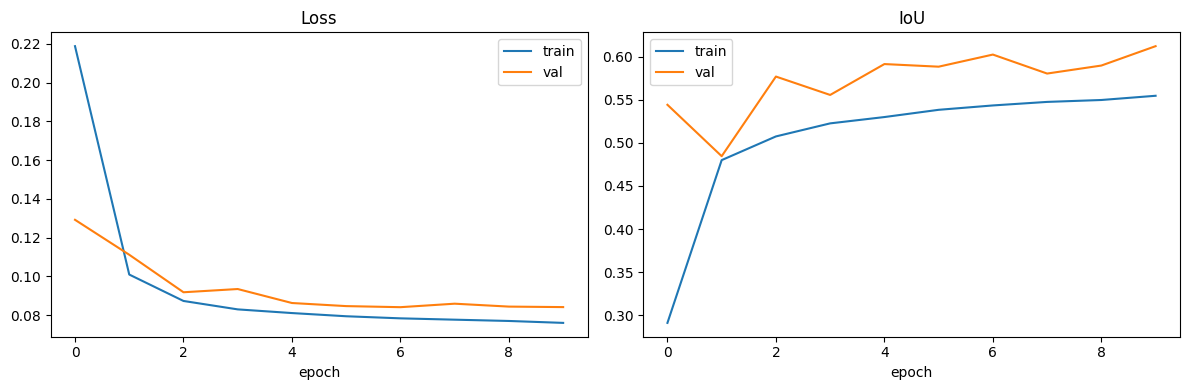

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history["train_iou"], label="train")
axes[1].plot(history["val_iou"], label="val")
axes[1].set_title("IoU")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()

### Test metrics

In [7]:
test_loss, test_iou = evaluate(model, TEST_IMG_DIR, TEST_MASK_DIR, val_transforms, TILE_SIZE, INFER_STRIDE)
print(f"test_loss={test_loss:.4f} | test_iou={test_iou:.4f}")


100%|██████████| 49/49 [00:38<00:00,  1.26it/s]

test_loss=0.0556 | test_iou=0.6225


### Test predictions

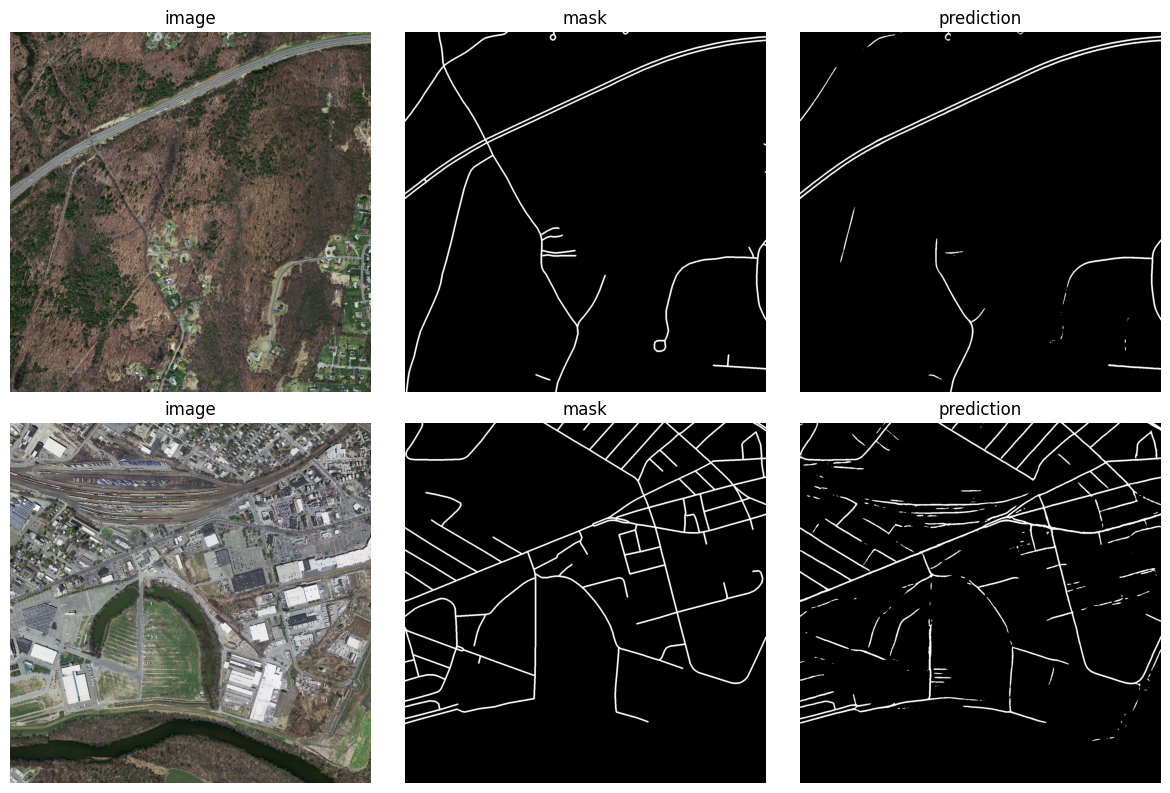

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, image_name in enumerate(sorted(os.listdir(TEST_IMG_DIR))[:2]):
    image_path = os.path.join(TEST_IMG_DIR, image_name)
    mask_path = os.path.join(TEST_MASK_DIR, f"{os.path.splitext(image_name)[0]}.tif")

    image, pred = predict_full_image(model, image_path, val_transforms, TILE_SIZE, INFER_STRIDE)
    mask = (tiff.imread(mask_path) > 0).astype("float32")

    axes[row, 0].imshow(image)
    axes[row, 0].set_title("image")
    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("mask")
    axes[row, 2].imshow(pred > 0.5, cmap="gray")
    axes[row, 2].set_title("prediction")

for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
